In [4]:
import faiss
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [5]:
import faiss
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [6]:
embeddings = np.load(
    "../models/faiss_embeddings.npy"
)

labels = np.load(
    "../models/faiss_labels.npy"
)

print(embeddings.shape)
print(labels.shape)

(838, 512)
(838,)


In [7]:
index = faiss.IndexFlatIP(
    embeddings.shape[1]
)

index.add(
    embeddings.astype(np.float32)
)

print(
    "Vectors:",
    index.ntotal
)

Vectors: 838


In [8]:
correct = 0
total = len(embeddings)

for i in range(total):

    query = embeddings[i:i+1]

    scores, indices = index.search(
        query,
        2
    )

    predicted = labels[
        indices[0][1]
    ]

    actual = labels[i]

    if predicted == actual:
        correct += 1

accuracy = correct / total

print(
    f"Top-1 Accuracy: {accuracy:.4f}"
)

Top-1 Accuracy: 0.6527


In [9]:
correct = 0
total = len(embeddings)

for i in range(total):

    query = embeddings[i:i+1]

    scores, indices = index.search(
        query,
        6
    )

    predicted_labels = labels[
        indices[0][1:]
    ]

    actual = labels[i]

    if actual in predicted_labels:
        correct += 1

top5_accuracy = correct / total

print(
    f"Top-5 Accuracy: {top5_accuracy:.4f}"
)

Top-5 Accuracy: 0.9809


In [10]:
same_scores = []

for i in range(len(embeddings)):

    query = embeddings[i:i+1]

    scores, indices = index.search(
        query,
        2
    )

    same_scores.append(
        scores[0][1]
    )

print(
    "Mean Same-Cow Similarity:",
    np.mean(same_scores)
)

Mean Same-Cow Similarity: 0.9268922


In [11]:
different_scores = []

for i in range(len(embeddings)):

    query = embeddings[i:i+1]

    scores, indices = index.search(
        query,
        20
    )

    actual = labels[i]

    for score, idx in zip(
        scores[0][1:],
        indices[0][1:]
    ):

        if labels[idx] != actual:

            different_scores.append(score)
            break

print(
    "Mean Different-Cow Similarity:",
    np.mean(different_scores)
)

Mean Different-Cow Similarity: 0.6016113


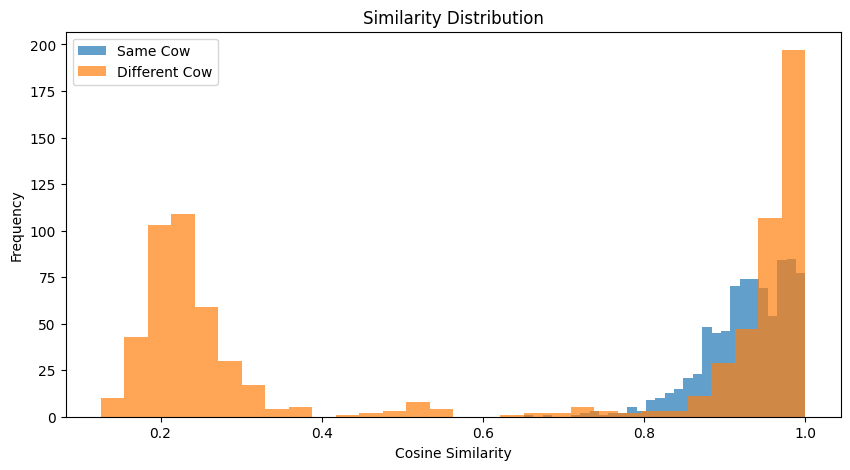

In [12]:
plt.figure(figsize=(10,5))

plt.hist(
    same_scores,
    bins=30,
    alpha=0.7,
    label="Same Cow"
)

plt.hist(
    different_scores,
    bins=30,
    alpha=0.7,
    label="Different Cow"
)

plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title(
    "Similarity Distribution"
)

plt.legend()

plt.show()

In [13]:
thresholds = np.arange(
    0.50,
    1.00,
    0.05
)

for t in thresholds:

    tp = sum(
        s >= t
        for s in same_scores
    )

    fp = sum(
        s >= t
        for s in different_scores
    )

    tpr = tp / len(same_scores)

    fpr = fp / len(different_scores)

    print(
        f"Threshold={t:.2f} | "
        f"TPR={tpr:.3f} | "
        f"FPR={fpr:.3f}"
    )

Threshold=0.50 | TPR=1.000 | FPR=0.526
Threshold=0.55 | TPR=1.000 | FPR=0.511
Threshold=0.60 | TPR=1.000 | FPR=0.509
Threshold=0.65 | TPR=1.000 | FPR=0.507
Threshold=0.70 | TPR=0.998 | FPR=0.505
Threshold=0.75 | TPR=0.989 | FPR=0.494
Threshold=0.80 | TPR=0.977 | FPR=0.490
Threshold=0.85 | TPR=0.918 | FPR=0.483
Threshold=0.90 | TPR=0.739 | FPR=0.457
Threshold=0.95 | TPR=0.383 | FPR=0.352


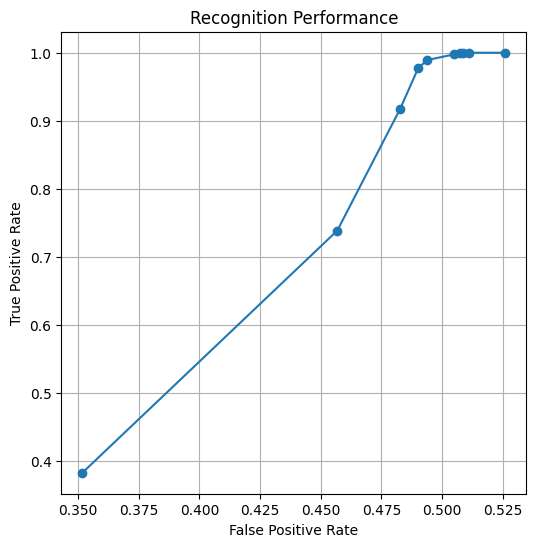

In [14]:
tprs = []
fprs = []

for t in thresholds:

    tp = sum(
        s >= t
        for s in same_scores
    )

    fp = sum(
        s >= t
        for s in different_scores
    )

    tprs.append(
        tp / len(same_scores)
    )

    fprs.append(
        fp / len(different_scores)
    )

plt.figure(figsize=(6,6))

plt.plot(
    fprs,
    tprs,
    marker="o"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Recognition Performance"
)

plt.grid(True)

plt.show()

In [15]:
best_threshold = 0.70

tp = sum(s >= best_threshold for s in same_scores)
fn = sum(s < best_threshold for s in same_scores)

fp = sum(s >= best_threshold for s in different_scores)
tn = sum(s < best_threshold for s in different_scores)

print("TP:", tp)
print("FN:", fn)
print("FP:", fp)
print("TN:", tn)

TP: 836
FN: 2
FP: 409
TN: 401


In [16]:
precision = tp / (tp + fp)

recall = tp / (tp + fn)

f1 = (
    2 * precision * recall
    / (precision + recall)
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.6715
Recall    : 0.9976
F1 Score  : 0.8027
